In [19]:
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os


In [20]:
adata = sc.read('/home/ratopin/big_data/annotated/all_regions_annotated.h5ad')

In [22]:
celltypes = pd.read_csv('manual_annotation_all_regions.csv', index_col=0)
celltypes

,celltype,subtype
AAACCCAAGAAGCGAA-1-NMR1,Glutamatergic Projection Neuron,Developing Layer II-IV Projection Neuron
AAACCCAAGGAGGCAG-1-NMR1,Glutamatergic Projection Neuron,Developing Layer VI Projection Neuron
AAACCCACAAATCAAG-1-NMR1,Glutamatergic Projection Neuron,Developing Layer VI Projection Neuron
AAACCCACAGTCTACA-1-NMR1,Glutamatergic Projection Neuron,Developing Layer II-IV Projection Neuron
AAACCCAGTACGTAGG-1-NMR1,Glutamatergic Projection Neuron,Developing Layer II-IV Projection Neuron
...,...,...
TTGCCTGTCCTTCACG-1-NMR6,Ependymal,Choroid Plexus Epithelial Cell
TTGCTGCTCGTTGCCT-1-NMR6,Ependymal,Choroid Plexus Epithelial Cell
TTGGTTTCAATGGCAG-1-NMR6,Ependymal,Choroid Plexus Epithelial Cell
TTTATGCGTTAAACAG-1-NMR6,Ependymal,Choroid Plexus Epithelial Cell


In [23]:
adata.obs[['celltype', 'subtype']] = celltypes.loc[adata.obs_names, ['celltype', 'subtype']]

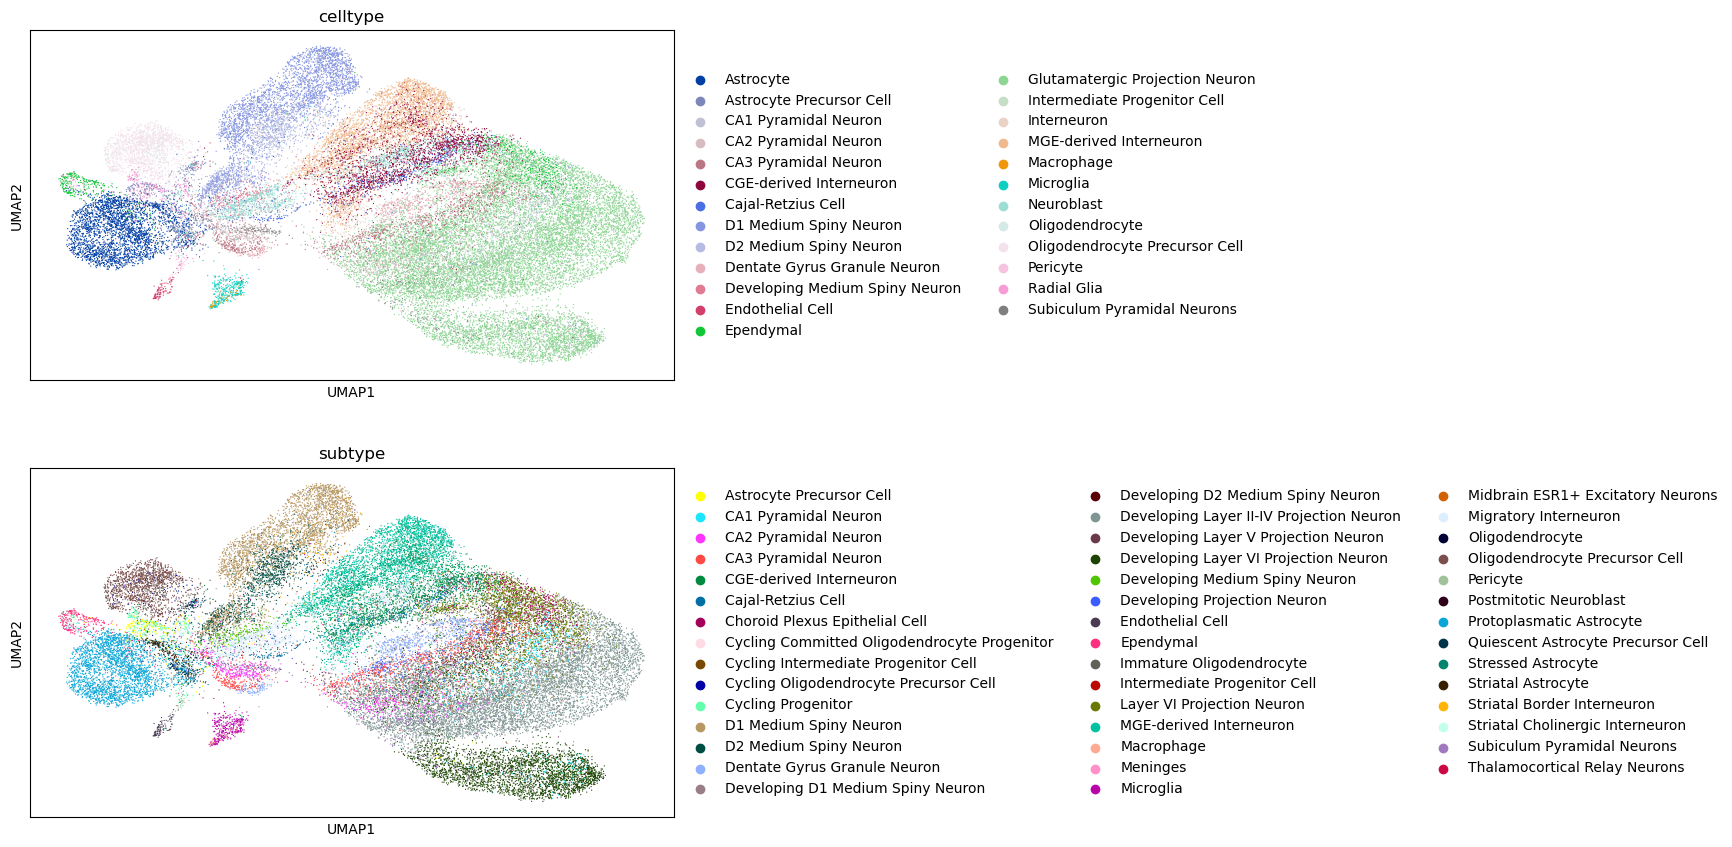

In [24]:
sc.pl.umap(adata, color=['celltype', 'subtype'], wspace=0.4, ncols=1)

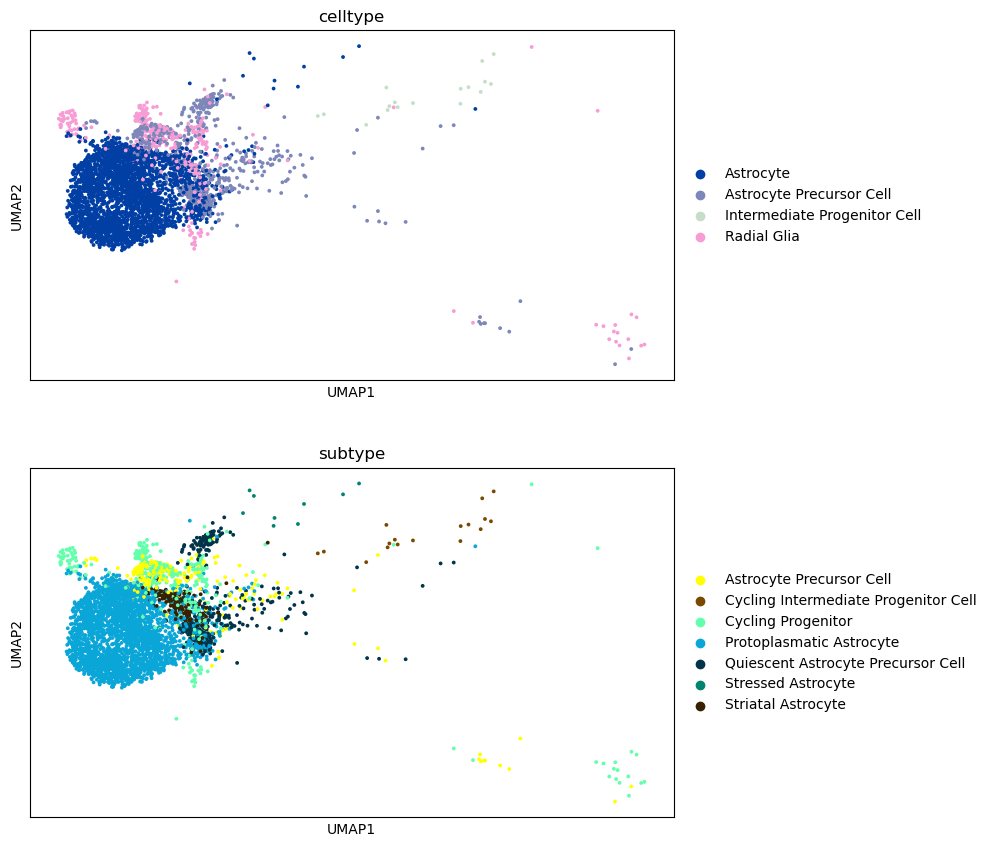

In [ ]:
sc.pl.umap(adata[adata.obs['subtype'].isin(['Stressed Astrocyte', 'Cycling Intermediate Progenitor Cell', 'Quiescent Astrocyte Precursor Cell','Cycling Progenitor','Striatal Astrocyte', 'Astrocyte Precursor Cell','Protoplasmatic Astrocyte'])], color=['celltype', 'subtype'], wspace=0.4, ncols=1)

In [8]:
# 1. Get the unique subclusters that contain Astrocytes
lookup_str = ''
first_mask = adata.obs['celltype'].str.contains(lookup_str, na=False)
groupby_col = 'subtype'
groups = adata.obs.loc[first_mask, groupby_col].unique()

most_expr_neu = {}
print(f'Most expressed genes in {groupby_col} and containing "{lookup_str}"')
# 2. Loop through those subclusters, maintaining the Astrocyte filter
for gr in groups:
    sub_adata = adata[(adata.obs[groupby_col] == gr) & (first_mask)]
    
    # Calculate the mean expression across ONLY these specific cells
    mean_expression = sub_adata.X.toarray().mean(axis=0)
    
    # Sort and get the top 40 genes
    top_expressed_genes = adata.var_names[np.argsort(mean_expression)[::-1][:20]].to_list()
    
    most_expr_neu[gr] = top_expressed_genes
    print(f"({sub_adata.n_obs} cells) {gr} : {top_expressed_genes}\t")

Most expressed genes in subtype and containing ""
(8751 cells) Developing Layer II-IV Projection Neuron : ['SATB2', 'TAFA1', 'NWD2', 'CNTN3', 'GRM1', 'MEF2C', 'UNC5C', 'ADAMTSL1', 'CPNE8', 'PVRL3', 'ZNF385B', 'DOK5', 'DLG1', 'DGKH', 'PTPRK', 'RAPGEF5', 'KCNH7', 'ARHGAP44', 'MPPED1', 'KCNH5']	
(3584 cells) Developing Layer VI Projection Neuron : ['TLE4', 'KIAA1217', 'DLC1', 'ZFPM2', 'SOX5', 'PDE1A', 'MYLK', 'DOK6', 'GRIK3', 'Oprm1', 'MCC', 'FOXP2', 'IGSF21', 'CDH18', 'KHDRBS3', 'MPPED1', 'SH3GL2', 'RGS6', 'DPP10', 'GARNL3']	
(3523 cells) MGE-derived Interneuron : ['METAP1D', 'NXPH1', 'KCNC2', 'ERBB4', 'GRIK1', 'UBASH3B', 'RBMS3', 'ELAVL2', 'GRIP1', 'LHX6', 'PTPRM', 'GRIA4', 'GAD1', 'PPIP5K2', 'GALNTL6', 'HAT1', 'COL25A1', 'GAD2', 'SPOCK3', 'ZNF536']	
(684 cells) Developing Layer V Projection Neuron : ['EPHA3', 'TAFA1', 'SLIT3', 'TENM1', 'NDST4', 'TRPS1', 'ENSHGLG00000008731', 'EPHA6', 'ENSHGLG00000001121', 'AK5', 'SLIT2', 'SPHKAP', 'DAB1', 'ACVR2A', 'FAM19A2', 'NEBL', 'KCNIP4', 'NTNG1',

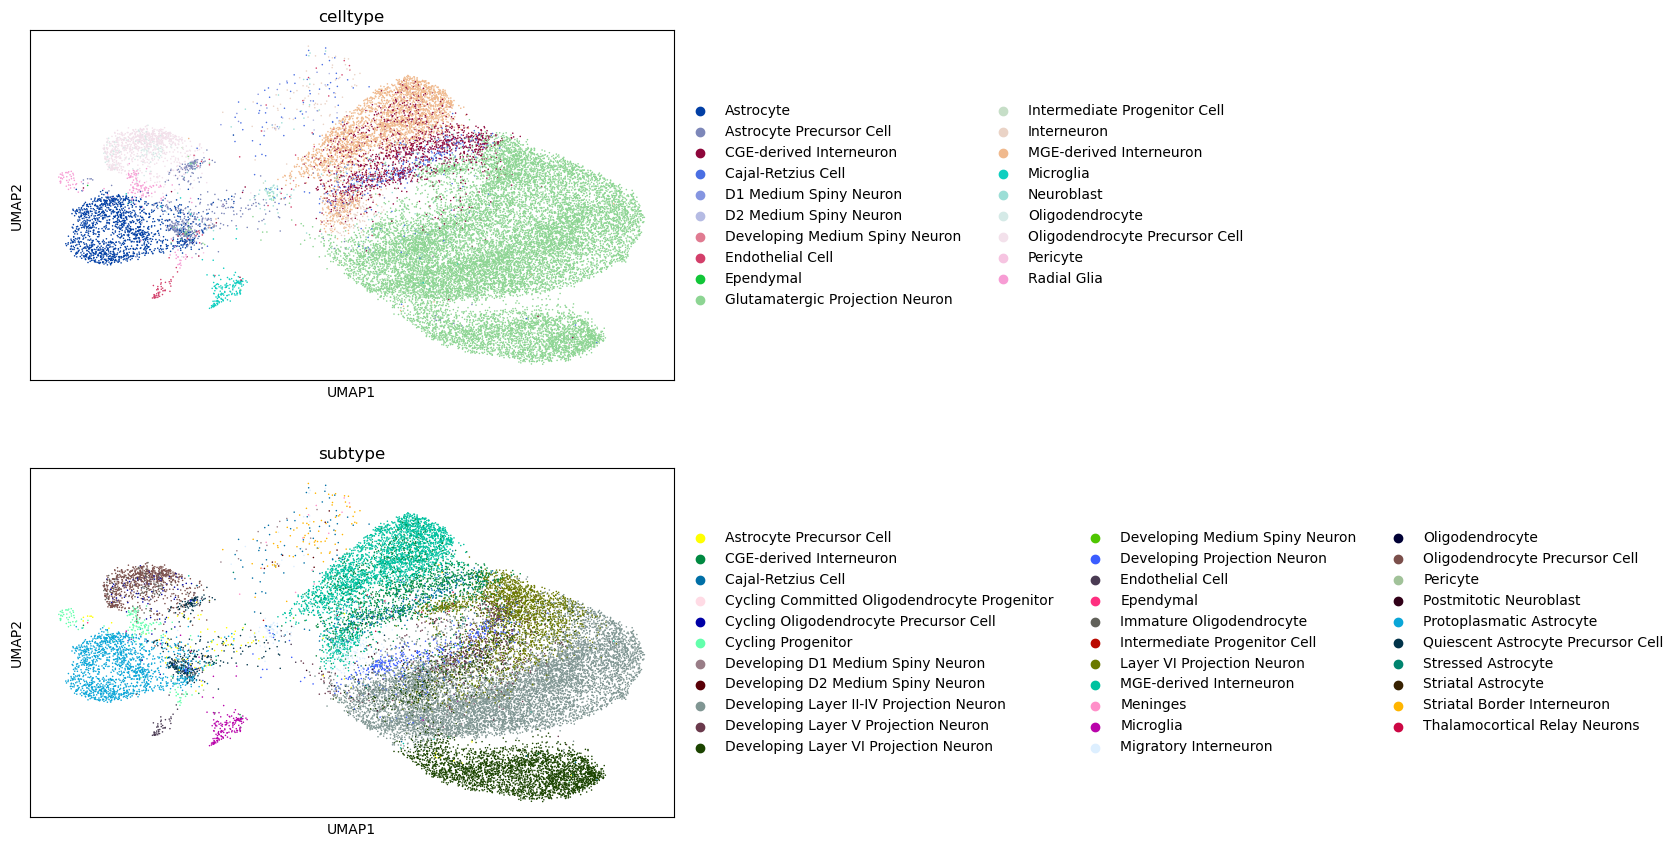

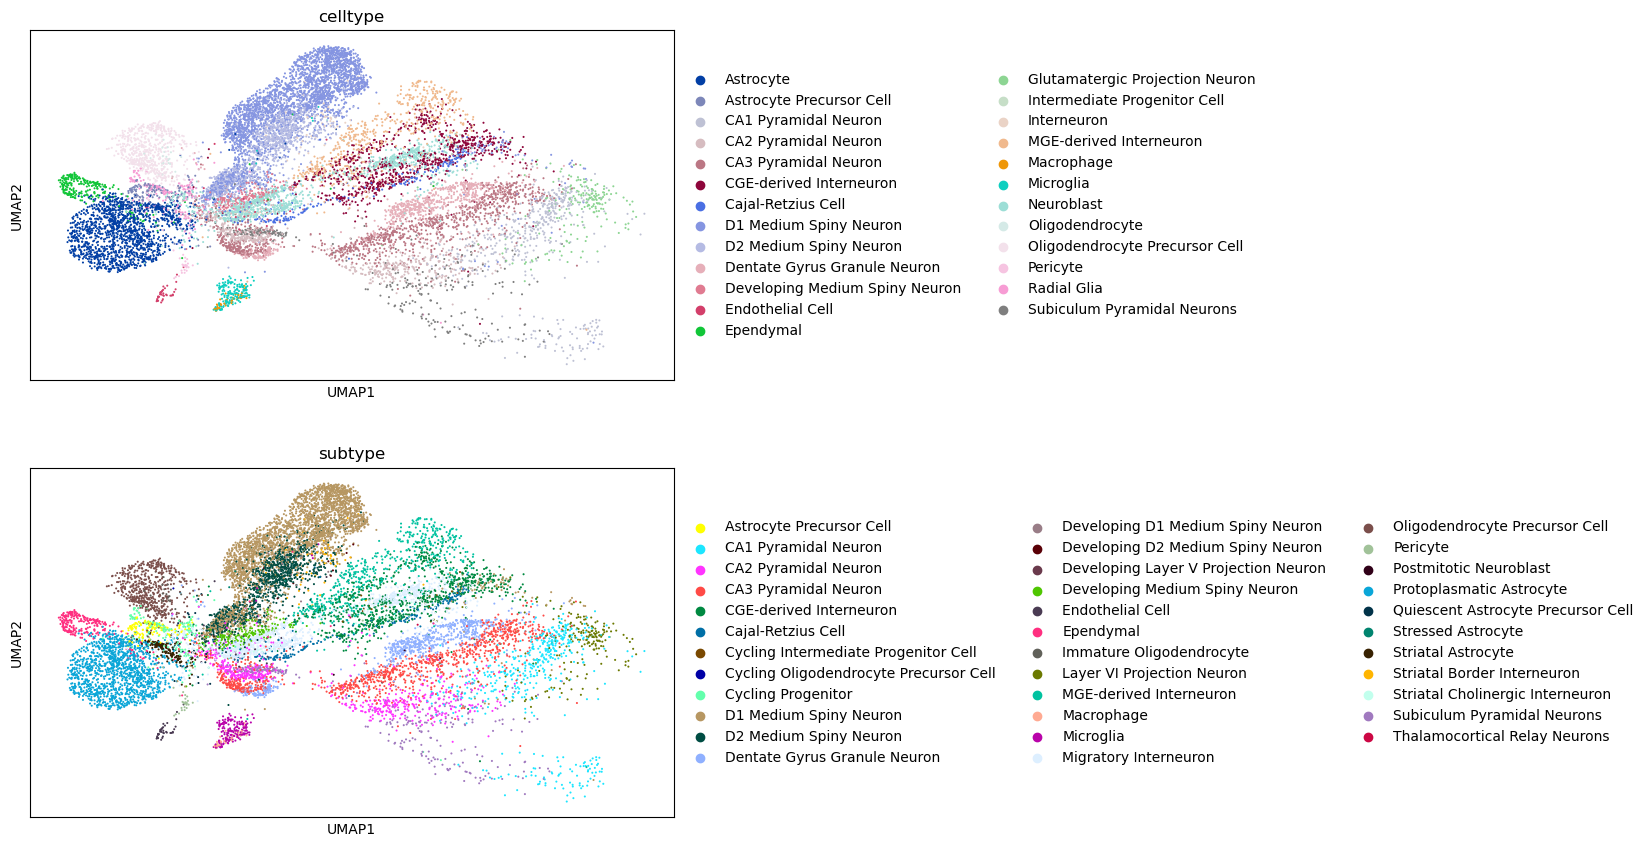

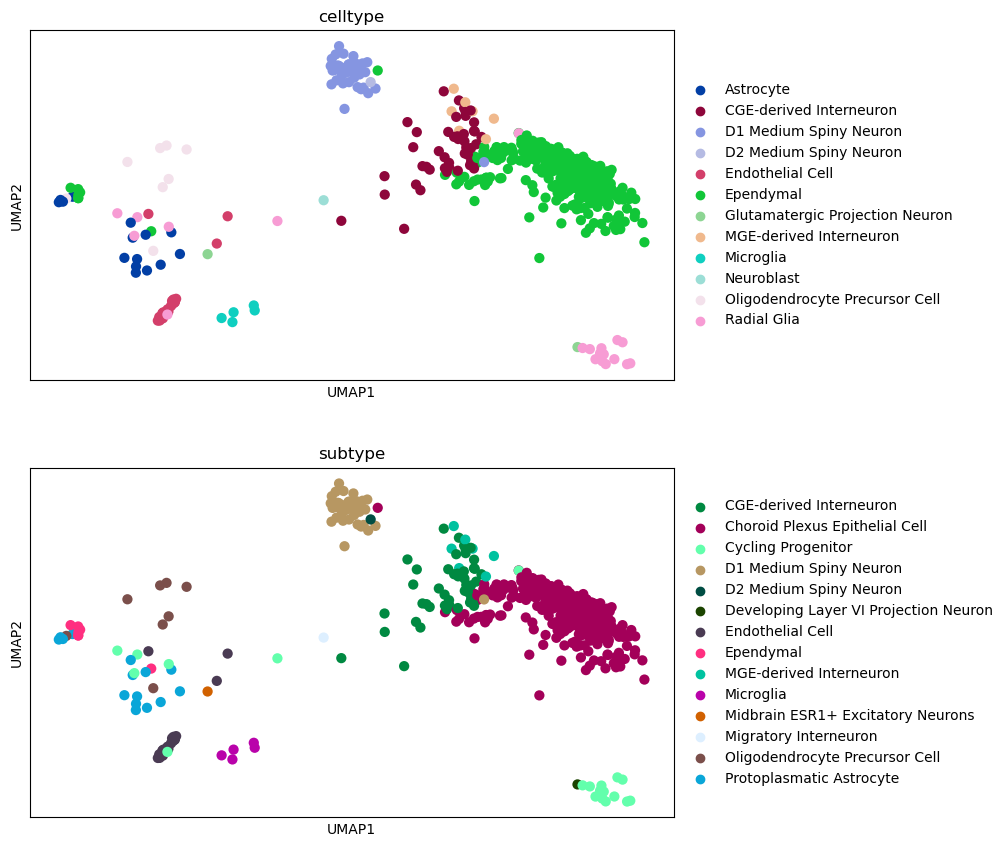

In [ ]:
for region in ['Cerebral cortex', 'Hippocampus', 'Midbrain']:
    sc.pl.umap(adata[adata.obs['region']==region], color=['celltype', 'subtype'], wspace=0.4, ncols=1, )

In [ ]:
from pathlib import Path
import sys

# Find the repository root
repo_root = Path("__file__").resolve().parents[1]

# Add the repository root to Python's search path
if str(repo_root) not in sys.path:
    sys.path.append(str(repo_root))

# Now you can import directly from your scripts folder!
from scripts.plot_functions import plot_composition

/home/ratopin/single-nucleus-nmr/scripts/plot_functions.py:81: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


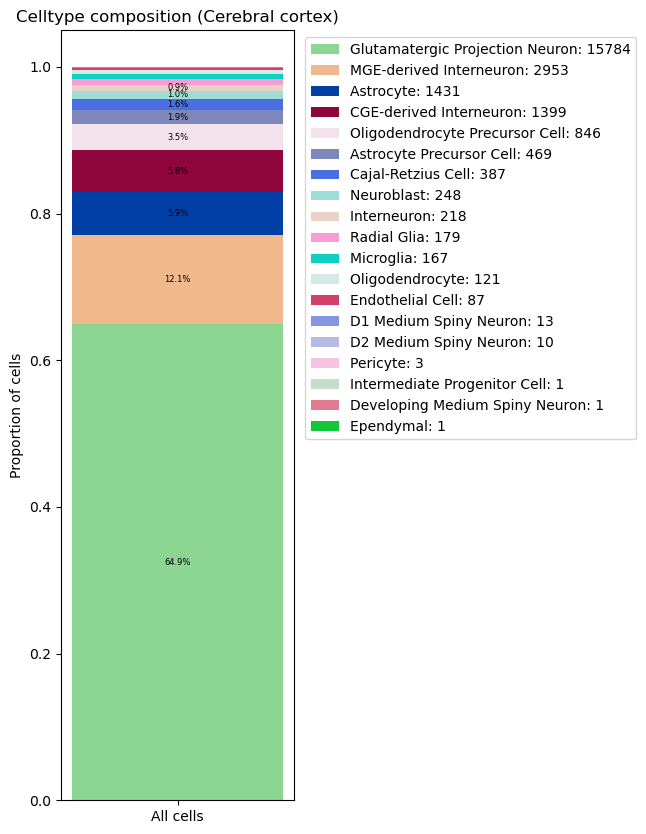

/home/ratopin/single-nucleus-nmr/scripts/plot_functions.py:81: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


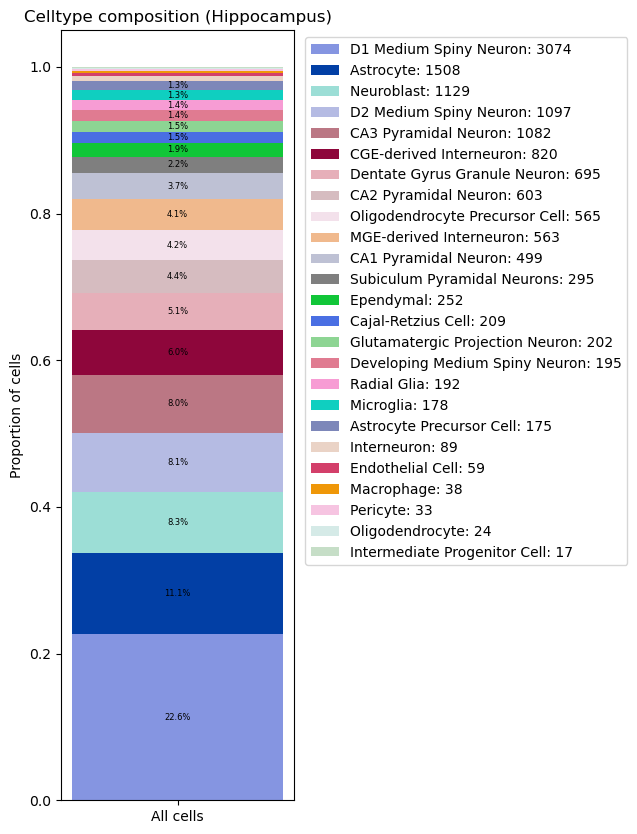

/home/ratopin/single-nucleus-nmr/scripts/plot_functions.py:81: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


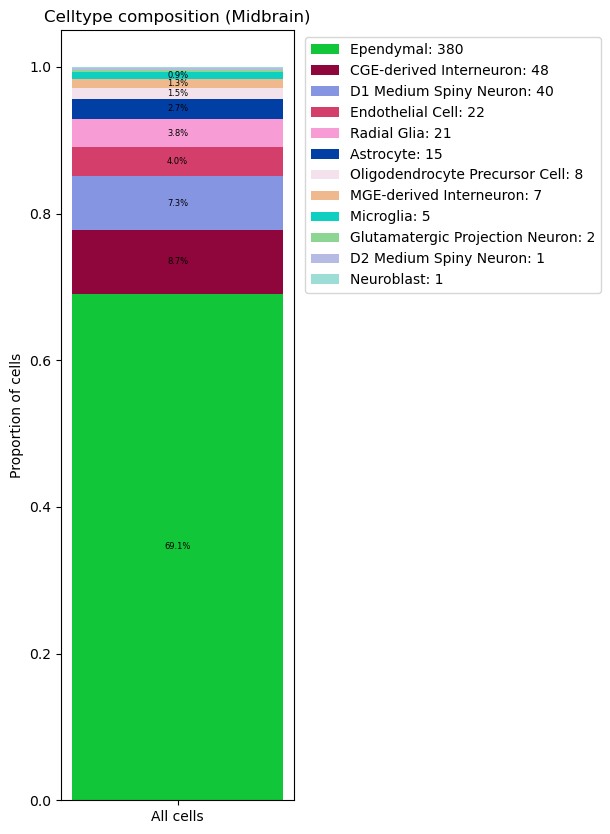

In [26]:
for region in ['Cerebral cortex', 'Hippocampus', 'Midbrain']:
    plot_composition(adata[adata.obs['region']==region,:], region, 'celltype', save_path=f'../results/{region}_refined_cell_composition.png')